# L8 2D convection-diffusion with boundary surface reaction

## Background

This notebook the couping of a two-dimensional convection-diffusion equation with a surface reaction on a wall. The lower wall has its own surface state:

- the gas-phase surface concentrations are extra unknowns;
- those gas surface concentrations are the Dirichlet boundary values for the bulk;
- gas surface equations balance wall-normal flux and surface reaction source terms;
- additional surface species obey implicit accumulation plus reaction terms.

The implementation uses `construct_grad(..., shapes_d=...)` to expose the boundary values as a separate variable block and `update_array_indices` to embed local sparse operators into one monolithic Jacobian.

## Governing Equations

For gas species A and B in the bulk, the transient convection-diffusion equation is solved with backward Euler:

$$
\frac{c_i^{n+1}-c_i^n}{\Delta t} + \nabla \cdot \left(\mathbf{u}c_i^{n+1} - D \nabla c_i^{n+1}\right)=0.
$$

At the catalytic lower wall, the bulk concentration is constrained by the surface gas variables:

$$
c_i(z,y=0)=c_{i,s}(z).
$$

The gas surface variables are algebraic. Their wall-normal diffusive flux is balanced against the gas part of the surface mechanism:

$$
-D\left.\frac{\partial c_A}{\partial y}\right|_s = - r_{ads},
\qquad
-D\left.\frac{\partial c_B}{\partial y}\right|_s = r_{des}.
$$

The surface species are `A*`, two-site `B*`, and vacancies `*`:

$$
A_s + * \rightarrow A*, \qquad A* + A* \rightarrow B*, \qquad B* \rightarrow B_s + 2*.
$$

They are also advanced with backward Euler:

$$
\frac{\theta^{n+1}-\theta^n}{\Delta t}=R_{surface}(c_s^{n+1},\theta^{n+1}).
$$


Because `B*` occupies two sites, the conserved site occupancy is

$$
\theta_A + 2\theta_B + \theta_* = 1.
$$


## Parameters and Assumptions

The bulk shape is `(n_z, n_y, n_gas)`. The global state is stored as a two-dimensional block array `(n_z, n_bulk_fields + n_surface_fields)` so that each axial cell contains its bulk cross-section and its surface state.


In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import identity
from pymrm import (
    NumJac,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    newton,
    update_array_indices,
)


In [10]:
@dataclass
class Surface2DConfig:
    n_z: int = 40
    n_y: int = 30
    n_gas: int = 2
    n_theta: int = 3
    length: float = 1.0
    height: float = 0.15
    velocity: float = 1.0
    d_ax: float = 0.01
    d_y: float = 0.02
    c_in: tuple[float, float] = (1.0, 0.0)
    k_ads: float = 2.0
    k_rxn: float = 1.0
    k_des: float = 0.7
    dt: float = 0.05
    n_steps: int = 20
    tol: float = 1.0e-9
    maxfev: int = 20


cfg = Surface2DConfig()


## PyMRM Implementation

The lower wall Dirichlet values are not constants. In the transverse gradient operator, `shapes_d=((n_z, 1, n_gas), None)` creates a matrix that maps the separate surface gas variables into the lower-wall boundary contribution. All matrices are kept in CSC format so `update_array_indices` can embed the bulk, surface-gas, and surface-species blocks into the global Jacobian.

The time derivative is represented as a constant sparse identity block for the bulk gas variables. The previous bulk state and previous surface coverages are updated after every successful implicit time step.


In [ ]:
class SurfaceReaction2DModel:
    def __init__(self, cfg: Surface2DConfig):
        self.cfg = cfg
        self.n_bulk_fields = cfg.n_y * cfg.n_gas
        self.n_surface_fields = cfg.n_gas + cfg.n_theta
        self.bulk_shape = (cfg.n_z, cfg.n_y, cfg.n_gas)
        self.bulk_block_shape = (cfg.n_z, self.n_bulk_fields)
        self.surface_shape = (cfg.n_z, self.n_surface_fields)
        self.surface_gas_shape = (cfg.n_z, cfg.n_gas)
        self.theta_shape = (cfg.n_z, cfg.n_theta)
        self.global_shape = (cfg.n_z, self.n_bulk_fields + self.n_surface_fields)
        self._build_grid()
        self._init_state()
        self._build_operators()
        self.numjac_surface = NumJac(self.surface_shape)
        self.snapshots = [{"time": 0.0, "u": self.u.copy()}]

    def _build_grid(self):
        cfg = self.cfg
        self.z_f = np.linspace(0.0, cfg.length, cfg.n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.y_f = np.linspace(0.0, cfg.height, cfg.n_y + 1)
        self.y_c = 0.5 * (self.y_f[:-1] + self.y_f[1:])

    def _init_state(self):
        cfg = self.cfg
        self.u = np.zeros(self.global_shape)
        bulk = self.bulk(self.u)
        bulk[..., 0] = cfg.c_in[0]
        bulk[..., 1] = cfg.c_in[1]
        surface = self.surface(self.u)
        surface[:, 0] = cfg.c_in[0]
        surface[:, 1] = cfg.c_in[1]
        surface[:, 2] = 0.0  # A*
        surface[:, 3] = 0.0  # B*
        surface[:, 4] = 1.0  # vacant sites
        self.bulk_old = bulk.copy()
        self.theta_old = surface[:, cfg.n_gas :].copy()

    def bulk(self, u):
        return u[:, : self.n_bulk_fields].reshape(self.bulk_shape)

    def surface(self, u):
        return u[:, self.n_bulk_fields :]

    def _embed(self, matrix, row_shape, col_shape, row_offset, col_offset):
        return update_array_indices(
            matrix,
            (row_shape, col_shape),
            (self.global_shape, self.global_shape),
            offset=(row_offset, col_offset),
        )

    def _build_operators(self):
        cfg = self.cfg
        c_in = np.array(cfg.c_in).reshape(1, 1, cfg.n_gas)

        bc_z = (
            {"a": cfg.d_ax, "b": cfg.velocity, "d": cfg.velocity * c_in},
            {"a": 1.0, "b": 0.0, "d": np.zeros((1, 1, cfg.n_gas))},
        )
        conv_z_mat, conv_z_bc = construct_convflux_upwind(
            self.bulk_shape, self.z_f, self.z_c, bc=bc_z, v=cfg.velocity, axis=0)
        grad_z_mat, grad_z_bc = construct_grad(
            self.bulk_shape, self.z_f, self.z_c, bc=bc_z, axis=0)
        div_z_mat = construct_div(self.bulk_shape, self.z_f, nu=0, axis=0)
        jac_z = div_z_mat @ (conv_z_mat - cfg.d_ax * grad_z_mat)
        g_z = (div_z_mat @ (conv_z_bc - cfg.d_ax * grad_z_bc)).toarray().reshape(self.bulk_shape)

        # Lower wall Dirichlet value is supplied by the surface gas variables.
        # Upper wall is no flux.
        bc_y = (
            {"a": 0.0, "b": 1.0, "d": np.ones((cfg.n_z, 1, cfg.n_gas))},
            {"a": 1.0, "b": 0.0, "d": np.zeros((cfg.n_z, 1, cfg.n_gas))},
        )
        grad_y_mat, grad_y_bc_lower, _grad_y_bc_upper = construct_grad(
            self.bulk_shape,
            self.y_f,
            self.y_c,
            bc=bc_y,
            axis=1,
            shapes_d=((cfg.n_z, 1, cfg.n_gas), None)
        )
        div_y_mat = construct_div(self.bulk_shape, self.y_f, nu=0, axis=1)
        jac_y_bulk = div_y_mat @ (-cfg.d_y * grad_y_mat)
        jac_y_surface = div_y_mat @ (-cfg.d_y * grad_y_bc_lower)

        self.jac_transport = self._embed(
            jac_z + jac_y_bulk,
            self.bulk_block_shape,
            self.bulk_block_shape,
            (0, 0),
            (0, 0),
        )
        self.jac_transport += self._embed(
            jac_y_surface,
            self.bulk_block_shape,
            self.surface_gas_shape,
            (0, 0),
            (0, self.n_bulk_fields),
        )

        bulk_identity = identity(np.prod(self.bulk_block_shape)) / cfg.dt
        self.jac_bulk_accumulation = self._embed(
            bulk_identity,
            self.bulk_block_shape,
            self.bulk_block_shape,
            (0, 0),
            (0, 0),
        )

        self.g_const = np.zeros(self.global_shape)
        self.g_const[:, : self.n_bulk_fields] = g_z.reshape(self.bulk_block_shape)

        # Reuse the same lower-wall gradient pieces for the surface gas flux balances.
        z_ids = np.arange(cfg.n_z).reshape(-1, 1)
        gas_ids = np.arange(cfg.n_gas).reshape(1, -1)
        lower_face_rows = np.ravel_multi_index(
            (z_ids, np.zeros((cfg.n_z, 1), dtype=int), gas_ids),
            (cfg.n_z, cfg.n_y + 1, cfg.n_gas),
        ).ravel()
        flux_from_bulk = cfg.d_y * grad_y_mat[lower_face_rows, :]
        flux_from_surface = cfg.d_y * grad_y_bc_lower[lower_face_rows, :]

        self.jac_transport += self._embed(
            flux_from_bulk,
            self.surface_gas_shape,
            self.bulk_block_shape,
            (0, self.n_bulk_fields),
            (0, 0),
        )
        self.jac_transport += self._embed(
            flux_from_surface,
            self.surface_gas_shape,
            self.surface_gas_shape,
            (0, self.n_bulk_fields),
            (0, self.n_bulk_fields),
        )
        self.jac_linear = self.jac_transport + self.jac_bulk_accumulation

    def surface_reaction_residual(self, surface):
        cfg = self.cfg
        c_A_s = surface[:, 0]
        theta_A = surface[:, 2]
        theta_B = surface[:, 3]
        theta_v = surface[:, 4]

        r_ads = cfg.k_ads * c_A_s * theta_v
        r_dim = cfg.k_rxn * theta_A**2
        r_des = cfg.k_des * theta_B

        residual = np.zeros_like(surface)
        residual[:, 0] = -r_ads
        residual[:, 1] = r_des
        residual[:, 2] = (theta_A - self.theta_old[:, 0]) / cfg.dt - (r_ads - 2.0 * r_dim)
        residual[:, 3] = (theta_B - self.theta_old[:, 1]) / cfg.dt - (r_dim - r_des)
        residual[:, 4] = (theta_v - self.theta_old[:, 2]) / cfg.dt - (-r_ads + 2.0 * r_des)
        return residual

    def residual(self, u):
        u = u.reshape(self.global_shape)
        surface = self.surface(u)
        g = self.g_const + (self.jac_linear @ u.ravel()).reshape(self.global_shape)
        g[:, : self.n_bulk_fields] -= self.bulk_old.reshape(self.bulk_block_shape) / self.cfg.dt
        g_surface, jac_surface = self.numjac_surface(self.surface_reaction_residual, surface)
        g[:, self.n_bulk_fields :] += g_surface
        jac = self.jac_linear + self._embed(
            jac_surface,
            self.surface_shape,
            self.surface_shape,
            (0, self.n_bulk_fields),
            (0, self.n_bulk_fields),
        )
        return g.ravel(), jac

    def step(self):
        result = newton(self.residual, self.u, tol=self.cfg.tol, maxfev=self.cfg.maxfev)
        self.u = result.x.reshape(self.global_shape)
        self.bulk_old = self.bulk(self.u).copy()
        self.theta_old = self.surface(self.u)[:, self.cfg.n_gas :].copy()
        return result

    def solve(self):
        rows = []
        for step in range(self.cfg.n_steps):
            result = self.step()
            time = (step + 1) * self.cfg.dt
            surface = self.surface(self.u)
            self.snapshots.append({"time": time, "u": self.u.copy()})
            rows.append(
                {
                    "step": step + 1,
                    "time": time,
                    "success": result.success,
                    "Newton iterations": result.nit,
                    "residual norm": np.linalg.norm(result.fun, ord=np.inf),
                    "outlet A average": self.bulk(self.u)[-1, :, 0].mean(),
                    "outlet B average": self.bulk(self.u)[-1, :, 1].mean(),
                    "mean theta_A": surface[:, 2].mean(),
                    "mean theta_B": surface[:, 3].mean(),
                    "mean theta_v": surface[:, 4].mean(),
                }
            )
        return pd.DataFrame(rows)

    def site_balance_error(self):
        theta = self.surface(self.u)[:, self.cfg.n_gas :]
        site_occupancy = theta[:, 0] + 2.0 * theta[:, 1] + theta[:, 2]
        return np.max(np.abs(site_occupancy - 1.0))


## Results


In [12]:
model = SurfaceReaction2DModel(cfg)
history = model.solve()
history.tail()


,step,time,success,Newton iterations,residual norm,outlet A average,outlet B average,mean theta_A,mean theta_B,mean theta_v
15,16,0.80,True,4,4.583001e-13,0.212468,0.007009,0.138749,0.007044,0.847163
16,17,0.85,True,4,3.943512e-13,0.198928,0.008239,0.143015,0.007919,0.841146
17,18,0.90,True,4,3.836931e-13,0.187452,0.009594,0.147085,0.008833,0.835249
18,19,0.95,True,4,4.742873e-13,0.177852,0.011080,0.150970,0.009784,0.829463
19,20,1.00,True,4,3.659295e-13,0.169931,0.012703,0.154684,0.010767,0.823781


In [13]:
_next_step_g, jac = model.residual(model.u)
final_step_residual_norm = history["residual norm"].iloc[-1]
summary = pd.Series(
    {
        "final time": history["time"].iloc[-1],
        "final step residual norm": final_step_residual_norm,
        "next step initial residual norm": np.linalg.norm(_next_step_g, ord=np.inf),
        "Jacobian nnz": jac.nnz,
        "outlet A average": model.bulk(model.u)[-1, :, 0].mean(),
        "outlet B average": model.bulk(model.u)[-1, :, 1].mean(),
        "weighted site-balance error": model.site_balance_error(),
    }
)
summary


final time                         1.000000e+00
final step residual norm           3.659295e-13
next step initial residual norm    3.683840e-01
Jacobian nnz                       1.244000e+04
outlet A average                   1.699315e-01
outlet B average                   1.270338e-02
weighted site-balance error        4.440892e-16
dtype: float64

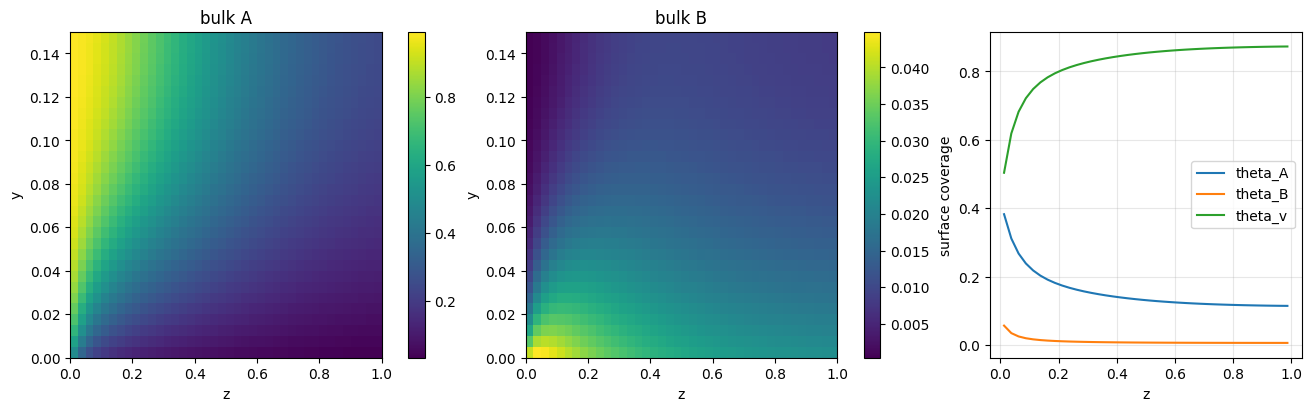

In [14]:
bulk = model.bulk(model.u)
surface = model.surface(model.u)

fig, ax = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
mesh0 = ax[0].pcolormesh(model.z_f, model.y_f, bulk[:, :, 0].T, shading="auto")
ax[0].set_title("bulk A")
ax[0].set_xlabel("z")
ax[0].set_ylabel("y")
fig.colorbar(mesh0, ax=ax[0])

mesh1 = ax[1].pcolormesh(model.z_f, model.y_f, bulk[:, :, 1].T, shading="auto")
ax[1].set_title("bulk B")
ax[1].set_xlabel("z")
ax[1].set_ylabel("y")
fig.colorbar(mesh1, ax=ax[1])

ax[2].plot(model.z_c, surface[:, 2], label="theta_A")
ax[2].plot(model.z_c, surface[:, 3], label="theta_B")
ax[2].plot(model.z_c, surface[:, 4], label="theta_v")
ax[2].set_xlabel("z")
ax[2].set_ylabel("surface coverage")
ax[2].legend()
ax[2].grid(True, alpha=0.3)
plt.show()


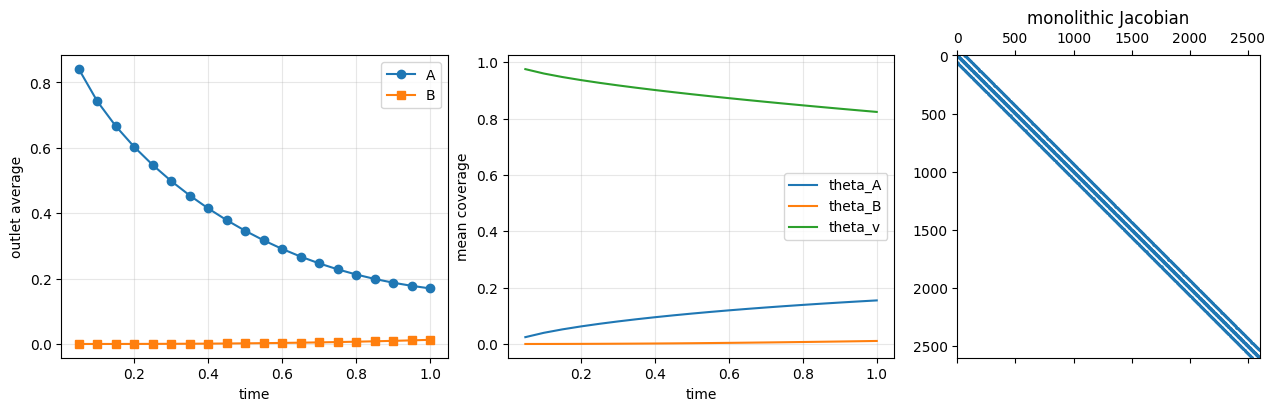

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
ax[0].plot(history["time"], history["outlet A average"], marker="o", label="A")
ax[0].plot(history["time"], history["outlet B average"], marker="s", label="B")
ax[0].set_xlabel("time")
ax[0].set_ylabel("outlet average")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history["time"], history["mean theta_A"], label="theta_A")
ax[1].plot(history["time"], history["mean theta_B"], label="theta_B")
ax[1].plot(history["time"], history["mean theta_v"], label="theta_v")
ax[1].set_xlabel("time")
ax[1].set_ylabel("mean coverage")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].spy(jac, markersize=0.5)
ax[2].set_title("monolithic Jacobian")
plt.show()


## Validation

The validation checks are deliberately simple:

- surface weighted surface site occupancy remains conserved;
- concentrations and coverages stay non-negative;
- the transient solution moves away from the uniform initial bulk state because A is adsorbed and converted at the wall;
- the final monolithic residual for the last implicit time step is small.


In [16]:
validation = pd.DataFrame(
    {
        "value": [
            f"{model.site_balance_error():.3e}",
            bool(np.all(model.bulk(model.u) >= -1.0e-10)),
            bool(np.all(model.surface(model.u) >= -1.0e-10)),
            bool(model.bulk(model.u)[-1, :, 0].mean() < cfg.c_in[0]),
            f"{final_step_residual_norm:.3e}",
            bool(final_step_residual_norm < 10 * cfg.tol),
        ]
    },
    index=[
        "weighted site-balance error",
        "bulk nonnegative",
        "surface nonnegative",
        "A outlet lower than inlet",
        "final step residual norm",
        "final step residual below tolerance",
    ],
)
validation


,value
weighted site-balance error,4.441e-16
bulk nonnegative,True
surface nonnegative,True
A outlet lower than inlet,True
final step residual norm,3.659e-13
final step residual below tolerance,True


## Discussion

This formulation separates three ideas that are often conflated:

- surface gas concentrations are boundary values for the bulk;
- flux balances determine those surface gas concentrations;
- additional surface species have their own accumulation and reaction equations.

The important PyMRM pattern is the combination of `shapes_d` for variable boundary data and `update_array_indices` for placing each local operator in the global monolithic state.
